In [1]:
import sys, socket, os
from pathlib import Path
protected = [Path.cwd() / 'data', Path.cwd() / 'upstream']
def audit_raw_writes(event, args):
    if event == 'open' and isinstance(args[0], (str, bytes, os.PathLike)):
        path = Path(os.fsdecode(args[0])).resolve()
        mode, flags = args[1], args[2]
        write = (isinstance(mode, str) and any(c in mode for c in 'wax+')) or (isinstance(flags, int) and flags & (os.O_WRONLY | os.O_RDWR | os.O_CREAT | os.O_TRUNC))
        if write and any(path == p or path.is_relative_to(p) for p in protected):
            raise RuntimeError('Protected raw write attempted: ' + str(path))
def no_network(*args, **kwargs):
    raise RuntimeError('Network disabled for inspection verification')
sys.dont_write_bytecode = True
sys.addaudithook(audit_raw_writes)
socket.socket.connect = no_network
socket.create_connection = no_network


# 全raw scanと全dataset token inspection

上から実行すると、保存済みinventoryではなく**現在のrawファイル**を読み、その後、全datasetのpromptをlocal tokenizerで計測します。
全体scanには数分かかる場合があります。data/はread-only。モデル推論・OpenAI API・simulation・学習・ダウンロードは行いません。

1〜8で全体を確認 → 9〜13で任意のrecordを確認 → 14〜18で全datasetのtokenを比較 → 19で保存済み結果を検算。
datasetを変えるときは9〜13だけ再実行できます。rawファイルが変わった場合は1から再実行してください。


## 1. imports / path

scan対象directory、実ファイルのschemaを取得する関数、reader、preprocessing、token counterを明示します。


In [2]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "dataset_adapters").is_dir() and (p / "configs/sources.json").is_file()), None)
if ROOT is None:
    raise RuntimeError("workspace直下またはnotebooks/から起動してください。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.inventory_llmx_data import create_inventory
from tools.inventory_candidates import scan
from dataset_adapters.base import inventory_context
from dataset_adapters.registry import get_adapter
from tools.live_inspection import (
    official_frames, external_frames, unified_overview, compare_frames, show_frame,
    token_summary_frame, compare_saved_tokens,
)
from tools.notebook_inspection import (
    dataset_table, select_record, preview_raw, preprocessing_for_inspection,
    selected_query, token_record, read_batch_summary,
)
from tools.count_input_tokens import resolve_encoding
from tools.token_inventory import build_token_inventory

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)
print("Official raw:", ROOT / "data/llmx_data")
print("External raw:", ROOT / "data/candidate_datasets")
print("No API clients. Scan/token results stay in memory; saved inventories are not overwritten.")


Official raw: /Users/cls-lab/Git/Matsuo/mental-modeling-openai/data/llmx_data
External raw: /Users/cls-lab/Git/Matsuo/mental-modeling-openai/data/candidate_datasets
No API clients. Scan/token results stay in memory; saved inventories are not overwritten.


## 2. LIVE SCAN: official raw

create_inventory()がoffline_data以下の全episode NPZをallow_pickle=Falseで読みます。
checkpoint等の非episodeファイルはmetadataのみ。shapeは実配列どおりで、singleton次元を削除しません。


In [3]:
llmx_inventory = create_inventory(ROOT / "data/llmx_data")
print("LIVE:", llmx_inventory["task_count"], "tasks,",
      llmx_inventory["episode_count"], "episodes,",
      llmx_inventory["total_timesteps"], "timesteps")


LIVE: 20 tasks, 172 episodes, 15200 timesteps


## 3. LIVE SCAN: external raw

scan()が現在取得済みの全ファイルを再帰scanします。
CSV/TXT/MAT/ULog/XLSXは既存の安全なreaderで確認し、code/model/media等はmetadataのみです。
opaque MATLAB objectは未解釈のまま示します。scan内の個別ファイルerrorも後の表に残し、成功扱いしません。


In [4]:
candidate_inventory = scan(ROOT / "data/candidate_datasets")
print("LIVE external files:", len(candidate_inventory["files"]))
print("Source size/mtime unchanged:", candidate_inventory["source_size_mtime_unchanged"])
print("Read errors:", sum(f["status"] == "error" for f in candidate_inventory["files"]))


Scanned 1000/34036


Scanned 2000/34036


Scanned 3000/34036


Scanned 4000/34036


Scanned 5000/34036


...

Scanned 31000/34036


Scanned 32000/34036


Scanned 33000/34036


Scanned 34000/34036


LIVE external files: 34036
Source size/mtime unchanged: True
Read errors: 0


## 4. official task overview

以下の3 DataFrameは、上で作ったllmx_inventory objectのみから整形します。


In [5]:
official_tasks_df, official_files_df, official_arrays_df = official_frames(llmx_inventory)
show_frame(official_tasks_df, title="LIVE official_tasks_df — 1 task / row")


,task,number_of_episodes,total_timesteps,timesteps_min,timesteps_max,timesteps_mean,state_dimensions,action_dimensions,action_kind,npz_keys,schema_consistent_except_T
0,MiniGrid-DoorKey-5x5-v0,24,226,7,13,9.416667,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
1,MiniGrid-Empty-Random-5x5-v0,11,30,1,6,2.727273,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
2,MiniGrid-Fetch-5x5-N2-v0,17,210,1,125,12.352941,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
3,MiniGrid-GoToDoor-5x5-v0,5,307,3,100,61.400000,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
4,MiniGrid-KeyCorridorS3R1-v0,11,162,14,15,14.727273,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
5,MiniGrid-Unlock-v0,10,130,9,22,13.000000,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
6,HalfCheetah-v4,3,3000,1000,1000,1000.000000,[17],[6],[continuous],"[actions, episodic_return, rewards, states]",True
7,Pusher-v4,6,600,100,100,100.000000,[23],[7],[continuous],"[actions, episodic_return, rewards, states]",True
8,Reacher-v4,5,250,50,50,50.000000,[11],[2],[continuous],"[actions, episodic_return, rewards, states]",True
9,Acrobot-v1,5,399,69,90,79.800000,[6],[1],[discrete],"[actions, episodic_return, rewards, states]",True


## 5. official全episode / array shape

official_files_dfは1 episode/file=1行、official_arrays_dfは1 file×1 NPZ key=1行です。
**全行を省略せずスクロール表示**します。任意の絞り込みもDataFrame.query()で可能です。


In [6]:
show_frame(official_files_df, title="LIVE official_files_df — all episodes")
show_frame(official_arrays_df, title="LIVE official_arrays_df — all file × NPZ key rows")
# 例: official_arrays_df.query("task == 'MountainCar-v0' and key == 'states'")


,task,episode_id,filename,relative_path,timesteps,size_bytes,schema_group
0,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,11,3547,e1b19ffbe0661f64
1,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,7,2815,e1b19ffbe0661f64
2,MiniGrid-DoorKey-5x5-v0,2,episode_1_seed2.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed2.npz,13,3913,e1b19ffbe0661f64
3,MiniGrid-DoorKey-5x5-v0,3,episode_2_seed41.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_2_seed41.npz,11,3547,e1b19ffbe0661f64
4,MiniGrid-DoorKey-5x5-v0,4,episode_2_seed42.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_2_seed42.npz,7,2815,e1b19ffbe0661f64
5,MiniGrid-DoorKey-5x5-v0,5,episode_2_seed45.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_2_seed45.npz,8,2998,e1b19ffbe0661f64
6,MiniGrid-DoorKey-5x5-v0,6,episode_3_seed141.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_3_seed141.npz,11,3547,e1b19ffbe0661f64
7,MiniGrid-DoorKey-5x5-v0,7,episode_3_seed142.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_3_seed142.npz,8,2998,e1b19ffbe0661f64
8,MiniGrid-DoorKey-5x5-v0,8,episode_3_seed145.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_3_seed145.npz,11,3547,e1b19ffbe0661f64
9,MiniGrid-DoorKey-5x5-v0,9,episode_4_seed123.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_4_seed123.npz,12,3730,e1b19ffbe0661f64


,task,episode_id,filename,relative_path,key,shape,dtype,ndim,num_elements
0,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,actions,"[11, 1]",int64,2,11
1,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,agent_dirs,"[11, 1]",int64,2,11
2,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,dir_vectors,"[11, 2]",int64,2,22
3,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,episodic_return,[1],float64,1,1
4,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,rewards,"[11, 1]",float32,2,11
5,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,states,"[11, 7, 7, 3]",uint8,4,1617
6,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,actions,"[7, 1]",int64,2,7
7,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,agent_dirs,"[7, 1]",int64,2,7
8,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,dir_vectors,"[7, 2]",int64,2,14
9,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,episodic_return,[1],float64,1,1


## 6. external全file / schema / column shape

candidate_inventory objectから作成。external_files_dfは全取得物、external_columns_dfはcolumn schema、
external_arrays_dfはMAT/NPZ/ULogの配列shape/dtypeです。CSVのdtypeはinventory readerの型解釈で、ファイル固有のbinary dtypeではありません。

外部は数万ファイルあるため、表示だけページに分けます。全件は各DataFrameに保持しています。
EXTERNAL_FILE_START / EXTERNAL_COLUMN_START / EXTERNAL_ARRAY_STARTを変更してこのセルを再実行するか、query()で絞り込めます。
missingが未報告の形式はnullであり0を捏造しません。


In [7]:
external_datasets_df, external_files_df, external_schema_groups_df, external_columns_df, external_arrays_df = external_frames(candidate_inventory)
EXTERNAL_FILE_START = 0
EXTERNAL_COLUMN_START = 0
EXTERNAL_ARRAY_START = 0
PAGE_SIZE = 100
show_frame(external_datasets_df, title="LIVE external_datasets_df")
show_frame(external_files_df, title="LIVE external_files_df", start=EXTERNAL_FILE_START, page_size=PAGE_SIZE)
show_frame(external_schema_groups_df, title="LIVE external_schema_groups_df")
show_frame(external_columns_df, title="LIVE external_columns_df", start=EXTERNAL_COLUMN_START, page_size=PAGE_SIZE)
show_frame(external_arrays_df, title="LIVE external_arrays_df", start=EXTERNAL_ARRAY_START, page_size=PAGE_SIZE)
scan_errors_df = external_files_df.query("status == 'error'")
if not scan_errors_df.empty:
    display(scan_errors_df)


,dataset,file_count,disk_bytes_excluding_git_cache,compressed_bytes_all_zip_including_nested,compressed_bytes_top_level,extracted_bytes_excluding_nested_zip,format_counts,schema_group_count,errors
0,aircombat_wez,17,462715,0,0,462715,"{'.csv': 12, 'no_extension': 1, '.md': 1, '.ipynb': 1, '.py': 1, '.txt': 1}",12,[]
1,calculated_moves,30606,1870335497,433793427,211171930,1436542070,"{'.zip': 4, '.txt': 12601, '.csv': 18001}",24,[]
2,f16capstone,210,256752038,0,0,256752038,"{'no_extension': 6, '.mat': 8, '.md': 35, '.py': 2, '.txt': 1, '.m': 35, '.heic': 1, '.mov': 1, '.ulg': 3, '.slx': 4, '.pdf': 58, '.png': 6, '.xlsx': 5, '.csv': 3, '.mpp': 1, '.f3z': 1, '.f3d': 1, '.stl': 1, '.jpg': 28, '.jpeg': 1, '.kml': 1, '.xml': 7, '.json': 1}",33,[]
3,trajair,3203,2464731087,316594152,316594152,2148136935,"{'.zip': 2, '.txt': 3089, '.csv': 112}",13,[]


,dataset,relative_path,format,size_bytes,rows,columns,schema_group,status
0,aircombat_wez,repository/Data/FactorialExperiment.csv,.csv,49720,864.0,10.0,aircombat_wez:15ed781ce07cec18,inspected
1,aircombat_wez,repository/Data/RandomExperiment_1000_NEZ.csv,.csv,52430,1000.0,10.0,aircombat_wez:3400173d0f20724e,inspected
2,aircombat_wez,repository/Data/RandomExperiment_1000_RMAX.csv,.csv,53865,1000.0,10.0,aircombat_wez:616c9b29c95caed1,inspected
3,aircombat_wez,repository/Data/RandomExperiment_1000_WEZ.csv,.csv,76481,1000.0,13.0,aircombat_wez:b2484680644a27b8,inspected
4,aircombat_wez,repository/LICENSE,no_extension,7048,121.0,NaN,aircombat_wez:8372931050a8036b,inspected
5,aircombat_wez,repository/Paper_Results/SummaryRMax_Lasso_Ridge_50_Reduction.csv,.csv,36823,60.0,39.0,aircombat_wez:cf7d844fac86530a,inspected
6,aircombat_wez,repository/Paper_Results/SummaryRMax_RF_50_.csv,.csv,1215,1.0,39.0,aircombat_wez:cf7d844fac86530a,inspected
7,aircombat_wez,repository/Paper_Results/SummaryRNez_RF_50_.csv,.csv,1218,1.0,39.0,aircombat_wez:f2520c736d775ba3,inspected
8,aircombat_wez,repository/Paper_Results/SummaryWez_Final_Results.csv,.csv,7030,7.0,53.0,aircombat_wez:3f2420d4132708e6,inspected
9,aircombat_wez,repository/Paper_Results/SummaryWez_Lasso_50_Preprocessing_Comparison.csv,.csv,35689,40.0,53.0,aircombat_wez:3f2420d4132708e6,inspected


,dataset,schema_group,file_count,rows,schema_kind,example_file
0,aircombat_wez,aircombat_wez:15ed781ce07cec18,1,864,delimited,repository/Data/FactorialExperiment.csv
1,aircombat_wez,aircombat_wez:3400173d0f20724e,1,1000,delimited,repository/Data/RandomExperiment_1000_NEZ.csv
2,aircombat_wez,aircombat_wez:616c9b29c95caed1,1,1000,delimited,repository/Data/RandomExperiment_1000_RMAX.csv
3,aircombat_wez,aircombat_wez:b2484680644a27b8,1,1000,delimited,repository/Data/RandomExperiment_1000_WEZ.csv
4,aircombat_wez,aircombat_wez:8372931050a8036b,2,127,unstructured_text,repository/LICENSE
5,aircombat_wez,aircombat_wez:cf7d844fac86530a,2,61,delimited,repository/Paper_Results/SummaryRMax_Lasso_Ridge_50_Reduction.csv
6,aircombat_wez,aircombat_wez:f2520c736d775ba3,1,1,delimited,repository/Paper_Results/SummaryRNez_RF_50_.csv
7,aircombat_wez,aircombat_wez:3f2420d4132708e6,4,88,delimited,repository/Paper_Results/SummaryWez_Final_Results.csv
8,aircombat_wez,aircombat_wez:5e10945a47b3304f,1,36,delimited,repository/Paper_Results/SummaryWez_Ridge_Lasso_PR_1to12.csv
9,aircombat_wez,aircombat_wez:a726919e93d47d7f,1,0,support_file,repository/README.md


,dataset,schema_group,column,dtype,rows,missing,schema_kind
0,aircombat_wez,aircombat_wez:15ed781ce07cec18,Case,int64,864,0.0,delimited
1,aircombat_wez,aircombat_wez:15ed781ce07cec18,BL_Speed,int64,864,0.0,delimited
2,aircombat_wez,aircombat_wez:15ed781ce07cec18,RD_Speed,int64,864,0.0,delimited
3,aircombat_wez,aircombat_wez:15ed781ce07cec18,rad,int64,864,0.0,delimited
4,aircombat_wez,aircombat_wez:15ed781ce07cec18,BL_Hdg,int64,864,0.0,delimited
5,aircombat_wez,aircombat_wez:15ed781ce07cec18,RD_Hdg,int64,864,0.0,delimited
6,aircombat_wez,aircombat_wez:15ed781ce07cec18,BL_Alt,float64,864,0.0,delimited
7,aircombat_wez,aircombat_wez:15ed781ce07cec18,RD_Alt,float64,864,0.0,delimited
8,aircombat_wez,aircombat_wez:15ed781ce07cec18,maxRange,float64,864,0.0,delimited
9,aircombat_wez,aircombat_wez:15ed781ce07cec18,minErrorTry,float64,864,0.0,delimited


,dataset,relative_path,format,key,shape,dtype,ndim,opaque
0,f16capstone,repository/FlightAxis/13_05_2021__16_16_38.mat,.mat,vals,[1],"[('_TypeSystem', 'O'), ('_Class', 'O'), ('_ObjectMetadata', 'O')]",1,True
1,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/timestamp,[119],uint64,1,False
2,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/armed_time_ms,[119],uint32,1,False
3,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/armed,[119],int8,1,False
4,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/prearmed,[119],int8,1,False
5,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/ready_to_arm,[119],int8,1,False
6,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/lockdown,[119],int8,1,False
7,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/manual_lockdown,[119],int8,1,False
8,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/force_failsafe,[119],int8,1,False
9,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/in_esc_calibration_mode,[119],int8,1,False


## 7. unified dataset overview

件数はlive scanから作ったreader単位で集計。capabilityはreaderの明示metadataで、shapeから意味を推測しません。
外部recordsは異種stream・別export・script等を含み、独立した物理trajectoryの数ではありません。
Baiduは未取得として表示します。


In [8]:
all_datasets_df = unified_overview(llmx_inventory, candidate_inventory)
show_frame(all_datasets_df, title="LIVE all_datasets_df")


,dataset,category,files,sequences,records,format,sequential,state_available,action_available,reward_available,status,record_scope
0,Acrobot-v1,official,5,5.0,399.0,[NPZ],True,True,True,True,acquired,episode timesteps
1,BipedalWalker-v3,official,2,2.0,144.0,[NPZ],True,True,True,True,acquired,episode timesteps
2,CartPole-v1,official,5,5.0,2500.0,[NPZ],True,True,True,True,acquired,episode timesteps
3,FetchPickAndPlace-v2,official,10,10.0,500.0,[NPZ],True,True,True,True,acquired,episode timesteps
4,FetchPush-v2,official,10,10.0,500.0,[NPZ],True,True,True,True,acquired,episode timesteps
5,FetchSlide-v2,official,10,10.0,500.0,[NPZ],True,True,True,True,acquired,episode timesteps
6,HalfCheetah-v4,official,3,3.0,3000.0,[NPZ],True,True,True,True,acquired,episode timesteps
7,InvertedDoublePendulum-v4,official,10,10.0,538.0,[NPZ],True,True,True,True,acquired,episode timesteps
8,InvertedPendulum-v4,official,5,5.0,1419.0,[NPZ],True,True,True,True,acquired,episode timesteps
9,LunarLander-v2,official,3,3.0,744.0,[NPZ],True,True,True,True,acquired,episode timesteps


## 8. LIVE SCAN vs SAVED INVENTORY — secondary validation

ここで初めて保存済みinventoryを読みます。ファイルがない場合もlive inspectionは可能です。
全件のkeyでouter joinし、新規／削除／shape・dtype変更・件数差を隠しません。
一致しなくてもrawを変更したりcacheを上書きしたりしません。


In [9]:
saved_base = ROOT / "outputs/dataset_inventory"
raw_validation = {}
if (saved_base / "llmx_schema.json").is_file() and (saved_base / "candidate_schema.json").is_file():
    saved_datasets = dataset_table()
    saved_llmx = json.loads((saved_base / "llmx_schema.json").read_text())
    saved_candidates = json.loads((saved_base / "candidate_schema.json").read_text())
    _, saved_official_files, saved_official_arrays = official_frames(saved_llmx)
    _, saved_external_files, saved_external_groups, saved_external_columns, saved_external_arrays = external_frames(saved_candidates)
    raw_validation["overview"] = compare_frames(
        all_datasets_df, saved_datasets.rename(columns={"dataset_id": "dataset"}),
        ["dataset"], ["files", "sequences", "records"])
    raw_validation["official_files"] = compare_frames(
        official_files_df, saved_official_files, ["task", "relative_path"], ["timesteps", "size_bytes", "schema_group"])
    raw_validation["official_arrays"] = compare_frames(
        official_arrays_df, saved_official_arrays, ["task", "relative_path", "key"],
        ["shape", "dtype", "ndim", "num_elements"])
    raw_validation["external_files"] = compare_frames(
        external_files_df, saved_external_files, ["dataset", "relative_path"],
        ["size_bytes", "rows", "columns", "schema_group", "status"])
    raw_validation["external_columns"] = compare_frames(
        external_columns_df, saved_external_columns, ["dataset", "schema_group", "column"],
        ["dtype", "rows", "missing"])
    raw_validation["external_arrays"] = compare_frames(
        external_arrays_df, saved_external_arrays, ["dataset", "relative_path", "key"],
        ["shape", "dtype", "ndim", "opaque"])
    display(pd.DataFrame([{"comparison": name, "rows": len(table),
                          "matches": int(table.matches.sum()), "differences": int((~table.matches).sum())}
                         for name, table in raw_validation.items()]))
    for name, table in raw_validation.items():
        if not table.matches.all():
            show_frame(table.loc[~table.matches], title=name + " differences", page_size=30)
else:
    print("Saved inventory not found. LIVE scan results remain the primary source.")


,comparison,rows,matches,differences
0,overview,25,25,0
1,official_files,172,172,0
2,official_arrays,904,904,0
3,external_files,34036,34036,0
4,external_columns,919,919,0
5,external_arrays,7432,7432,0


## 9. drill-down selection

全体を見た後、ここで初めてdatasetを選びます。0-basedです。
staticのROW_IDは全reader単位の累積IDで、ファイル内indexではありません。
section 18のqueryを調べる場合はdataset_id・episode/sequence_id・query_index・history_size・前処理設定をここへ転記し、9〜13だけ再実行してください。


In [10]:
DATASET = "MountainCar-v0"
EPISODE = 0
SEQUENCE_ID = None
ROW_ID = None
INDEX = 10

HISTORY_SIZE = 1
METRIC = None
QUESTION_NAME = None  # None/Noneでそのtaskの既存LLM-X既定質問。
MODEL = "gpt-4o"
# 外部は明示した既存設定のみ。例: "configs/preprocessing/f16capstone_default.yaml"
PREPROCESSING_CONFIG = None


## 10. selected raw record — RAW DATA

readerには同じlive inventoryを渡します。保存済みcacheをprimary sourceへ戻しません。
source file、選択sequence、全raw fieldのshape/dtypeと実値を表示します。


In [11]:
with inventory_context(llmx_inventory, candidate_inventory):
    adapter = get_adapter(DATASET)
sequence, raw_record = select_record(adapter, episode=EPISODE, sequence_id=SEQUENCE_ID, row_id=ROW_ID, index=INDEX)
if sequence is None:
    print("NOT_ACQUIRED: raw inspection unavailable.")
else:
    print("RAW RECORD")
    print("Source:", sequence.source_file, "\nSequence:", sequence.sequence_id, sequence.key)
    print("Episode:", raw_record["episode_id"], "Row:", raw_record.get("row_id"), "Index:", raw_record["index"])
    print("SHA256:", raw_record["source_file_sha256"])
    raw_fields_df = pd.DataFrame([{"field": name, **spec} for name, spec in raw_record["fields"].items()])
    show_frame(raw_fields_df, title="Selected raw fields")
    print(json.dumps(raw_record["fields"], ensure_ascii=False, indent=2))
    raw_preview = preview_raw(adapter, sequence)
    if isinstance(raw_preview, dict):
        for key, value in raw_preview.items():
            print("\n", key, "(episode scope)" if key == "episodic_return" else "[:5]")
            print(value)
    else:
        display(raw_preview)


RAW RECORD
Source: data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz 
Sequence: 0 offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz
Episode: 0 Row: None Index: 10
SHA256: c91b3e277decddff587601790c381096c5bab98fc726af94dba76d924e0ffa5b


,field,value,dtype,shape
0,states,"[[-0.45723235607147217, 0.006099471356719732]]",float32,"[1, 2]"
1,actions,[1],int64,[1]
2,rewards,[-1.0],float64,[1]
3,episodic_return,[[-105.0]],float32,"[1, 1]"


{
  "states": {
    "value": [
      [
        -0.45723235607147217,
        0.006099471356719732
      ]
    ],
    "dtype": "float32",
    "shape": [
      1,
      2
    ]
  },
  "actions": {
    "value": [
      1
    ],
    "dtype": "int64",
    "shape": [
      1
    ]
  },
  "rewards": {
    "value": [
      -1.0
    ],
    "dtype": "float64",
    "shape": [
      1
    ]
  },
  "episodic_return": {
    "value": [
      [
        -105.0
      ]
    ],
    "dtype": "float32",
    "shape": [
      1,
      1
    ]
  }
}

 states [:5]
[[[-0.49763566  0.        ]]

 [[-0.4968302   0.00080547]]

 [[-0.49522528  0.00160493]]

 [[-0.4928329   0.00239238]]

 [[-0.48967093  0.00316196]]]

 actions [:5]
[[2]
 [2]
 [2]
 [2]
 [2]]

 rewards [:5]
[[-1.]
 [-1.]
 [-1.]
 [-1.]
 [-1.]]

 episodic_return (episode scope)
[[-105.]]


## 11. PREPROCESSING → HISTORY

RAWとMODEL INPUT AFTER PREPROCESSINGは別です。公式は既存LLM-X関数のwrapperを使い、元promptの意味を変更しません。
外部は指定したYAMLのbaselineのみ。reward/actionを生成せず、未定義ならN/A。


In [12]:
config, preprocessing_status = preprocessing_for_inspection(DATASET, PREPROCESSING_CONFIG)
print(preprocessing_status)
query = None
if config is not None and sequence is not None:
    display(config)
    try:
        query = selected_query(adapter, sequence, raw_record["index"], config, HISTORY_SIZE, METRIC, QUESTION_NAME)
    except (ValueError, IndexError) as exc:
        print("Model input: N/A —", exc)
    if query is not None:
        print("MODEL INPUT AFTER PREPROCESSING:", config["prompt_mode"])
        print("Metric / question:", query.metric, query.question_name)
        print("H:", query.history_size, "history [start,end):", query.history_start, query.history_end)
        print("\nHISTORY\n", query.history_text)
else:
    print("Token count: N/A")


Model-input preprocessing: defined


{'name': 'llmx_original',
 'prompt_mode': 'original_llmx',
 'implementation': 'upstream/LLM-Xavier',
 'indexed_history': True,
 'numeric_precision': 4,
 'fetch_drop_last_state_feature': True,
 'semantics': 'upstream Episode/history_text/render_question/system_prompt/user_prompt unchanged'}

MODEL INPUT AFTER PREPROCESSING: original_llmx
Metric / question: next-action next_action_prediction
H: 1 history [start,end): 8 10

HISTORY
 Step 8:
  state: [[-0.4699,  0.006 ]]
  action: [2]
  reward: [-1.]

Step 9:
  state: [[-0.4633,  0.0065]]
  action: [1]
  reward: [-1.]


## 12. actual prompt全文

同じpreprocessingが作ったSYSTEM PROMPTとUSER PROMPT。文字列を表示するだけで送信しません。


In [13]:
if query is not None:
    print("Prompt mode:", config["prompt_mode"], "Preprocessing:", config["name"])
    print("\nSYSTEM PROMPT\n")
    print(query.system_prompt)
    print("\nUSER PROMPT\n")
    print(query.user_prompt)
else:
    print("Prompt: N/A")


Prompt mode: original_llmx Preprocessing: llmx_original

SYSTEM PROMPT

Below is a description of the "MountainCar-v0" task.

Task description:

        The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill.
        

Observation space:

        The observation is a ndarray with shape (2,) where the elements correspond to the following:
        position of the car along the x-axis (range from -1.2 to 0.6), velocity of the car (range from -0.07 to 0.07)
        

Action space:

        There are 3 discrete deterministic actions,
        0: Accelerate to the left
        1: Do not accelerate
        2: Accelerate to the right
        

Reward space:

        The goal is to reach the flag placed on top of 

## 13. selected query token

CLI共通count_queryを使用。contentは実文字列のlocal tokenize結果、API入力はcontent+9の既存概算でserver usageではありません。
history/questionはBPE境界のためuser_tokensに単純加算できません。fallback使用時は明示します。


In [14]:
selected_tokens = None
if query is not None:
    encoding, fallback = resolve_encoding(MODEL)
    selected_tokens = token_record(query, sequence, config, encoding, fallback, MODEL)
    print("Model:", MODEL, "Tokenizer:", encoding.name, "Fallback:", fallback)
    names = ["system_tokens", "history_tokens", "question_tokens", "user_tokens",
             "total_content_tokens", "estimated_api_input_tokens"]
    display(pd.DataFrame([{"component": k, "tokens": selected_tokens[k]} for k in names]))
else:
    print("Token count: N/A")


Model: gpt-4o Tokenizer: o200k_base Fallback: False


,component,tokens
0,system_tokens,407
1,history_tokens,65
2,question_tokens,144
3,user_tokens,229
4,total_content_tokens,636
5,estimated_api_input_tokens,645


## 14. LIVE TOKEN COUNT: all datasets

build_token_inventory()をCLIと共有し、**今回の実行で**prompt文字列を作りlocal tokenizeします。
選択datasetとは独立です。公式対応11 taskは全valid query、公式未対応9 taskと未取得Baiduは理由付きskip。
外部はconfigs/preprocessing/の明示された既存default設定を使い、巨大poolはseed固定sampling。
staticはH=0。sample総tokenは全件総tokenではありません。
結果はmemoryに保持し、保存済みbatchを上書きしません。


In [15]:
TOKEN_MODEL = "gpt-4o"
TOKEN_HISTORY_SIZES = [1]
TOKEN_EXTERNAL_FULL = False
TOKEN_EXTERNAL_SAMPLE_SIZE = 2000
TOKEN_EXTERNAL_SAMPLE_THRESHOLD = 100000
TOKEN_SEED = 0


In [16]:
with inventory_context(llmx_inventory, candidate_inventory):
    result = build_token_inventory(
        datasets="everything", history_sizes=TOKEN_HISTORY_SIZES, model=TOKEN_MODEL,
        external_full=TOKEN_EXTERNAL_FULL,
        external_sample_size=TOKEN_EXTERNAL_SAMPLE_SIZE,
        external_sample_threshold=TOKEN_EXTERNAL_SAMPLE_THRESHOLD,
        seed=TOKEN_SEED,
    )
print("LIVE count:", result.metadata["number_of_datasets"], "datasets,",
      result.metadata["number_of_queries"], "query/history/static rows")
print("Tokenizer:", result.metadata["tokenizer"], "Fallback:", result.metadata["fallback_encoding_used"])
token_scopes_df = pd.DataFrame(result.scopes)
token_skipped_df = pd.DataFrame(result.skipped)
show_frame(token_scopes_df, title="LIVE scopes — full selected scope vs deterministic sample")
show_frame(token_skipped_df, title="Skipped datasets and reasons")


Acrobot-v1 H=1: full_selected_scope, 389/389 queries


CartPole-v1 H=1: full_selected_scope, 2490/2490 queries


FetchPickAndPlace-v2 H=1: full_selected_scope, 480/480 queries


FetchPush-v2 H=1: full_selected_scope, 480/480 queries


FetchSlide-v2 H=1: full_selected_scope, 480/480 queries


...

aircombat_wez H=0: full_selected_scope, 3864/3864 queries


calculated_moves H=0: deterministic_sample, 2000/2804268 queries


LIVE count: 15 datasets, 61000 query/history/static rows
Tokenizer: o200k_base Fallback: False


,dataset_id,prompt_mode,history_size,preprocessing_config_sha256,preprocessing_name,count_scope,eligible_query_pool,selected_source_units,dataset_reader_records,sample_size,seed,source_globs
0,Acrobot-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,389,5,399,389,0,"[""official episodes""]"
1,CartPole-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,2490,5,2500,2490,0,"[""official episodes""]"
2,FetchPickAndPlace-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,480,10,500,480,0,"[""official episodes""]"
3,FetchPush-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,480,10,500,480,0,"[""official episodes""]"
4,FetchSlide-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,480,10,500,480,0,"[""official episodes""]"
5,InvertedDoublePendulum-v4,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,518,10,538,518,0,"[""official episodes""]"
6,InvertedPendulum-v4,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,1409,5,1419,1409,0,"[""official episodes""]"
7,LunarLander-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,738,3,744,738,0,"[""official episodes""]"
8,MiniGrid-Unlock-v0,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,110,10,130,110,0,"[""official episodes""]"
9,MountainCar-v0,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,1021,10,1041,1021,0,"[""official episodes""]"


,dataset_id,reason
0,BipedalWalker-v3,task class/description absent from upstream registry; raw readable; no safe version alias
1,HalfCheetah-v4,task class/description absent from upstream registry; raw readable; no safe version alias
2,MiniGrid-DoorKey-5x5-v0,task class/description absent from upstream registry; raw readable; no safe version alias
3,MiniGrid-Empty-Random-5x5-v0,task class/description absent from upstream registry; raw readable; no safe version alias
4,MiniGrid-Fetch-5x5-N2-v0,task class/description absent from upstream registry; raw readable; no safe version alias
5,MiniGrid-GoToDoor-5x5-v0,task class/description absent from upstream registry; raw readable; no safe version alias
6,MiniGrid-KeyCorridorS3R1-v0,task class/description absent from upstream registry; raw readable; no safe version alias
7,Pusher-v4,task class/description absent from upstream registry; raw readable; no safe version alias
8,Reacher-v4,task class/description absent from upstream registry; raw readable; no safe version alias
9,baidu_fighter_jet,NOT_ACQUIRED


## 15. all_token_queries_df

1 query / history window / static record=1行。全計測行をmemory上のDataFrameとして保持します。
画面はページ表示だけですが、all_token_queries_df.query(...)で全件を直接検索できます。
episode_id / sequence_id / row_idは非該当ならNAです。


In [17]:
all_token_queries_df = pd.DataFrame(result.queries)
for col in ["episode_id", "sequence_id", "row_id", "query_index"]:
    all_token_queries_df[col] = all_token_queries_df[col].astype("Int64")
QUERY_START = 0
query_columns = [
    "dataset_id", "source_file", "episode_id", "sequence_id", "row_id", "query_index",
    "history_size", "prompt_mode", "preprocessing_name", "preprocessing_config_sha256",
    "estimated_api_input_tokens", "system_tokens", "user_tokens", "history_tokens", "question_tokens",
    "count_scope", "eligible_query_pool", "sample_size", "seed",
]
show_frame(all_token_queries_df[query_columns], title="LIVE all_token_queries_df", start=QUERY_START, page_size=100)
# 例: all_token_queries_df.query("dataset_id == 'MountainCar-v0' and episode_id == 0")
token_by_sequence_df = pd.DataFrame(result.by_sequence)


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed
0,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,2,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,888,573,306,117,169,full_selected_scope,389,389,0
1,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,3,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,888,573,306,116,170,full_selected_scope,389,389,0
2,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,4,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
3,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,5,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,118,169,full_selected_scope,389,389,0
4,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,6,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
5,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,7,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
6,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,8,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,118,169,full_selected_scope,389,389,0
7,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,9,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
8,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,10,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
9,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,11,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,888,573,306,117,169,full_selected_scope,389,389,0


## 16. token_by_dataset_df

dataset / mode / H / 前処理設定ごとに分離します。異なるprompt semanticsやsample scopeを混ぜて合算しません。
stdは母標準偏差、p95はnearest-rank（既存CLIと共通）です。


In [18]:
token_by_dataset_df = token_summary_frame(result)
summary_columns = [
    "dataset_id", "prompt_mode", "preprocessing_name", "history_size", "count_scope",
    "eligible_query_pool", "sample_size", "seed", "counted_queries", "mean", "std",
    "min", "median", "p95", "max", "total",
]
show_frame(token_by_dataset_df[summary_columns], title="LIVE token_by_dataset_df")


,dataset_id,prompt_mode,preprocessing_name,history_size,count_scope,eligible_query_pool,sample_size,seed,counted_queries,mean,std,min,median,p95,max,total
0,Acrobot-v1,original_llmx,llmx_original,1,full_selected_scope,389,389,0,389,887.868895,3.258492,880,888.0,890,910,345381
1,CartPole-v1,original_llmx,llmx_original,1,full_selected_scope,2490,2490,0,2490,830.610040,2.619846,825,830.0,833,845,2068219
2,FetchPickAndPlace-v2,original_llmx,llmx_original,1,full_selected_scope,480,480,0,480,2725.454167,13.663287,2643,2728.0,2736,2749,1308218
3,FetchPush-v2,original_llmx,llmx_original,1,full_selected_scope,480,480,0,480,2707.306250,7.648527,2625,2708.0,2716,2721,1299507
4,FetchSlide-v2,original_llmx,llmx_original,1,full_selected_scope,480,480,0,480,2744.916667,11.545261,2663,2746.0,2753,2765,1317560
5,InvertedDoublePendulum-v4,original_llmx,llmx_original,1,full_selected_scope,518,518,0,518,1550.810811,7.982058,1542,1549.0,1556,1592,803320
6,InvertedPendulum-v4,original_llmx,llmx_original,1,full_selected_scope,1409,1409,0,1409,1036.408801,2.283419,1030,1036.0,1039,1059,1460300
7,LunarLander-v2,original_llmx,llmx_original,1,full_selected_scope,738,738,0,738,1102.720867,25.266077,1074,1093.0,1168,1179,813808
8,MiniGrid-Unlock-v0,original_llmx,llmx_original,1,full_selected_scope,110,110,0,110,2145.000000,0.000000,2145,2145.0,2145,2145,235950
9,MountainCar-v0,original_llmx,llmx_original,1,full_selected_scope,1021,1021,0,1021,643.369246,2.651076,637,643.0,646,652,656880


## 17. dataset間token distribution

prompt_modeごとに図を分け、各datasetのpreprocessing_name・H・全件/sampleをラベルに表示します。
boxplotのひげは1.5×IQR、点はその外側。幅や点の数から未計測poolの分布を推定しません。


/var/folders/9v/4_0508ps1r79hjh0f80nm8800000gp/T/ipykernel_57339/2244758009.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


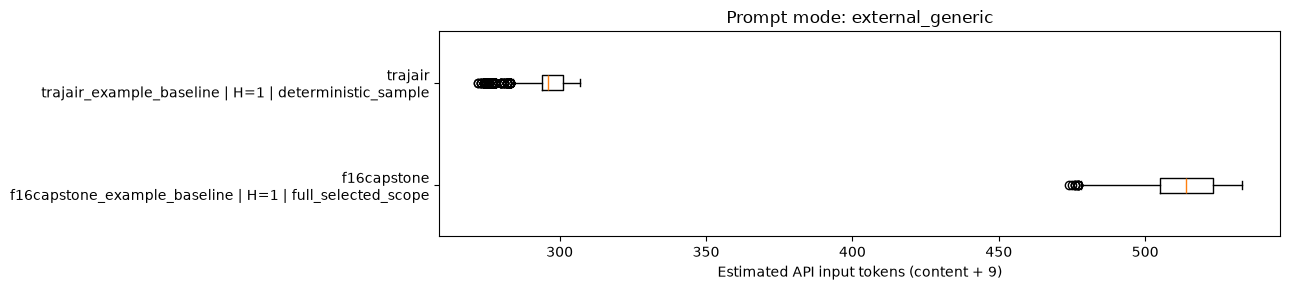

/var/folders/9v/4_0508ps1r79hjh0f80nm8800000gp/T/ipykernel_57339/2244758009.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


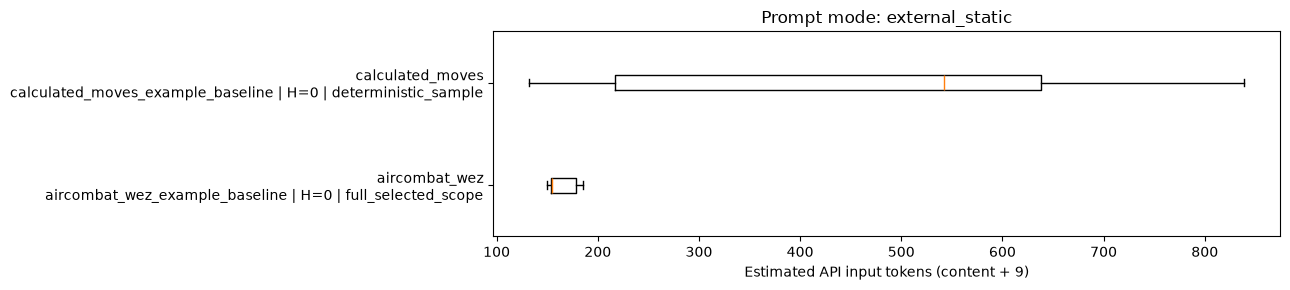

/var/folders/9v/4_0508ps1r79hjh0f80nm8800000gp/T/ipykernel_57339/2244758009.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


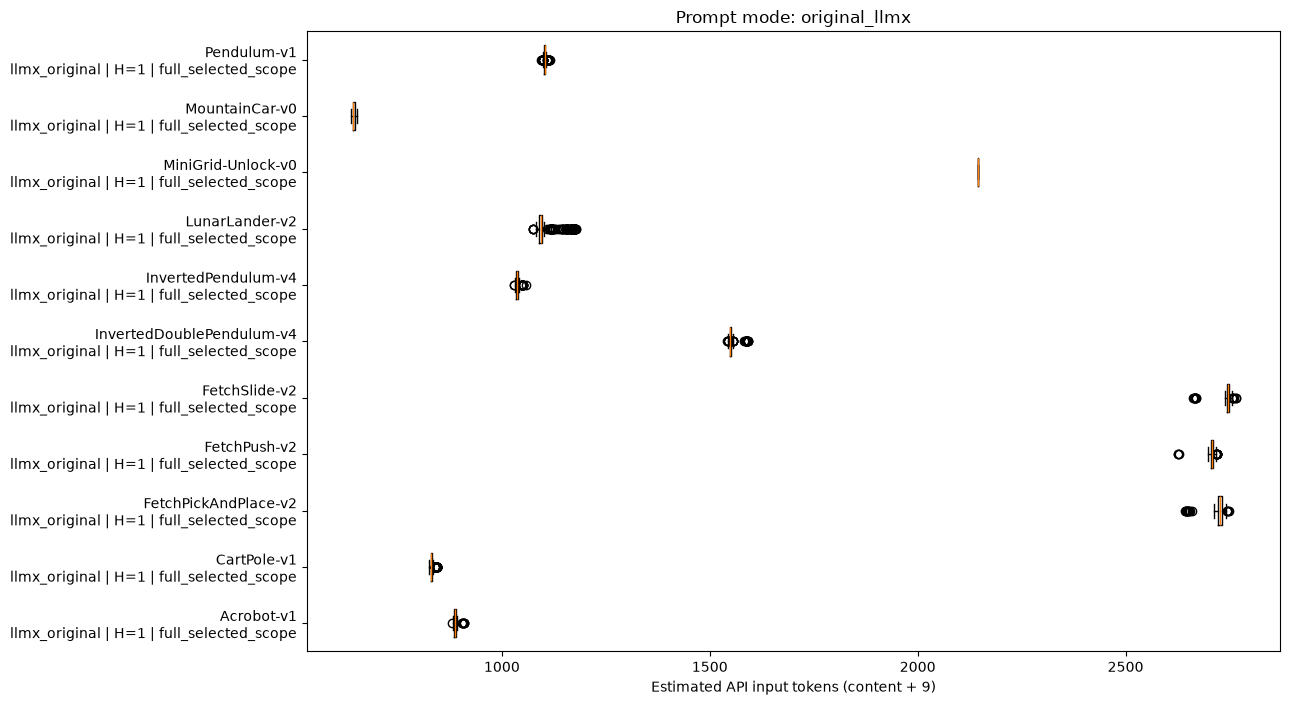

In [19]:
import matplotlib.pyplot as plt
for mode, mode_df in all_token_queries_df.groupby("prompt_mode", sort=True):
    grouped = list(mode_df.groupby(["dataset_id", "preprocessing_name", "history_size", "count_scope"], sort=True))
    labels = [f"{key[0]}\n{key[1]} | H={key[2]} | {key[3]}" for key, _ in grouped]
    values = [group["estimated_api_input_tokens"].to_numpy() for _, group in grouped]
    fig, ax = plt.subplots(figsize=(13, max(3, 0.65 * len(grouped))))
    ax.boxplot(values, vert=False)
    ax.set_yticks(range(1, len(labels) + 1), labels)
    ax.set_xlabel("Estimated API input tokens (content + 9)")
    ax.set_title(f"Prompt mode: {mode}")
    fig.tight_layout()
    plt.show()


## 18. largest/smallest token queries → raw/prompt drill-down

以下の行を見て、section 9の選択値を変更してください。query_indexは元sequence内のindex、row_idはstaticの全体IDです。
前処理設定・H・metric/questionも一致させて9〜13を再実行すると同じpromptを確認できます。
外部はPREPROCESSING_CONFIGも指定してください。各query行に実効設定JSONとSHA256を保持しています。


In [20]:
largest_token_queries_df = all_token_queries_df.nlargest(20, "estimated_api_input_tokens")
smallest_token_queries_df = all_token_queries_df.nsmallest(20, "estimated_api_input_tokens")
drill_columns = query_columns + ["metric", "question_name"]
show_frame(largest_token_queries_df[drill_columns], title="Largest 20 counted queries")
show_frame(smallest_token_queries_df[drill_columns], title="Smallest 20 counted queries")
example = largest_token_queries_df.iloc[0]
print("Example selection — copy into section 9:")
print("DATASET =", repr(example["dataset_id"]))
print("EPISODE =", int(example["episode_id"]) if pd.notna(example["episode_id"]) else None)
print("SEQUENCE_ID =", int(example["sequence_id"]))
print("ROW_ID =", int(example["row_id"]) if pd.notna(example["row_id"]) else None)
print("INDEX =", int(example["query_index"]))
print("HISTORY_SIZE =", int(example["history_size"]))
print("Metric/question:", example["metric"], example["question_name"])
print("Effective preprocessing JSON:", example["preprocessing_config"])


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed,metric,question_name
4276,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,7,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2765,1472,1284,587,677,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4277,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,8,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2765,1472,1284,588,676,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
3983,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_3_seed42.npz,3,3,<NA>,2,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2760,1472,1279,585,674,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4209,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_7_seed557.npz,7,7,<NA>,36,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2758,1472,1277,583,674,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4294,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,25,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2758,1472,1277,579,678,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4210,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_7_seed557.npz,7,7,<NA>,37,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2757,1472,1276,581,675,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
3984,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_3_seed42.npz,3,3,<NA>,3,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2756,1472,1275,581,674,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4295,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,26,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2756,1472,1275,580,675,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
3895,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_1_seed99.npz,1,1,<NA>,10,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2755,1472,1274,577,677,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4111,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_5_seed213.npz,5,5,<NA>,34,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2755,1472,1274,578,676,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed,metric,question_name
60262,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527145405/red2.csv,<NA>,21108,3430469,200,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60266,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527145435/red2.csv,<NA>,21132,3436626,42,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60278,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527151642/red2.csv,<NA>,21220,3459985,246,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60284,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527153626/red2.csv,<NA>,21284,3476609,30,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60351,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527183911/red2.csv,<NA>,21948,3651513,219,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60365,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527191539/red2.csv,<NA>,22076,3685066,92,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60253,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527143440/red2.csv,<NA>,21004,3403090,186,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,133,22,102,91,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60260,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527143758/red2.csv,<NA>,21060,3417865,226,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,133,22,102,91,11,deterministic_sample,2804268,2000,0,representation,baseline_description
60264,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/2015052714542

Example selection — copy into section 9:
DATASET = 'FetchSlide-v2'
EPISODE = 9
SEQUENCE_ID = 9
ROW_ID = None
INDEX = 7
HISTORY_SIZE = 1
Metric/question: next-action next_action_prediction_continuous_bins_fetch
Effective preprocessing JSON: {"fetch_drop_last_state_feature":true,"history_size":1,"implementation":"upstream/LLM-Xavier","indexed_history":true,"name":"llmx_original","numeric_precision":4,"prompt_mode":"original_llmx","semantics":"upstream Episode/history_text/render_question/system_prompt/user_prompt unchanged"}


## 19. optional: Saved batch resultsとのvalidation

read_batch_summary()はここだけで使用します。LIVE結果がprimaryです。
同じdataset・mode・H・設定SHA・model/tokenizer・sampling条件の集計値を比較し、savedのみのHも明示します。
比較は集計値レベルです。prompt全文の厳密一致を調べる場合はquery-levelのprompt SHAを照合してください。
savedがなければ表示するだけで、追加batchは起動しません。


In [21]:
saved_token_summary = read_batch_summary()
saved_metadata_path = ROOT / "outputs/token_counts/summary.json"
if saved_token_summary is None or not saved_metadata_path.is_file():
    print("Token batch has not been executed yet.")
else:
    saved_metadata = json.loads(saved_metadata_path.read_text())
    saved_token_validation_df = compare_saved_tokens(result, saved_token_summary, saved_metadata)
    show_frame(saved_token_validation_df, title="LIVE vs SAVED token aggregates")
    print("Matched aggregates:", int(saved_token_validation_df.matches.sum()))
    print("Saved results read only; no CSV/JSON was overwritten.")


,dataset_id,prompt_mode,history_size,preprocessing_config_sha256,n_units_live,eligible_query_pool_live,sample_size_live,seed_live,count_scope_live,mean_input_tokens_live,std_input_tokens_live,min_input_tokens_live,median_input_tokens_live,p95_input_tokens_live,max_input_tokens_live,total_input_tokens_live,n_units_saved,eligible_query_pool_saved,sample_size_saved,seed_saved,count_scope_saved,mean_input_tokens_saved,std_input_tokens_saved,min_input_tokens_saved,median_input_tokens_saved,p95_input_tokens_saved,max_input_tokens_saved,total_input_tokens_saved,presence,matches,model_tokenizer_match,comparison_note
0,Acrobot-v1,original_llmx,0,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7285faa3c88985c1d49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,394,394,394,0,"""full_selected_scope""",829.6040609137056,2.6877393660552023,824,830,832,851,326864,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
1,Acrobot-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,389,389,389,0,"""full_selected_scope""",887.8688946015424,3.2584924143051133,880,888,890,910,345381,389,389,389,0,"""full_selected_scope""",887.8688946015424,3.2584924143051133,880,888,890,910,345381,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
2,Acrobot-v1,original_llmx,2,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226df8beebfaa3eb54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,384,384,384,0,"""full_selected_scope""",946.1484375,3.7605888911969294,938,946,949,969,363321,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
3,Acrobot-v1,original_llmx,3,c0c4a33cf5f4d0c0bc4f4b7d57e8227c90e984b61cce883344e6c39b57036bee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379,379,379,0,"""full_selected_scope""",1004.4327176781004,4.279494674873803,996,1004,1008,1028,380680,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
4,Acrobot-v1,original_llmx,5,8f9e90a0f3fdba34c0f15aa6a4ae696fa21b4db2805e1982904c2e256b0481b1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,369,369,369,0,"""full_selected_scope""",1120.9783197831978,5.25651655400823,1112,1121,1126,1146,413641,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
5,Acrobot-v1,original_llmx,10,aa547e15a1fa5f9d58e077cd5bc5b80fa8ddc06e53de3a8ee897cabefd108d2a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,344,344,344,0,"""full_selected_scope""",1412.2877906976744,7.274219513981406,1400,1411,1429,1438,485827,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
6,CartPole-v1,original_llmx,0,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7285faa3c88985c1d49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2495,2495,2495,0,"""full_selected_scope""",785.4400801603207,2.0562034770579745,781,785,787,799,1959673,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
7,CartPole-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2490,2490,2490,0,"""full_selected_scope""",830.6100401606426,2.6198461737840137,825,830,833,845,2068219,2490,2490,2490,0,"""full_selected_scope""",830.6100401606426,2.6198461737840137,825,830,833,845,2068219,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
8,CartPole-v1,original_llmx,2,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226df8beebfaa3eb54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2485,2485,2485,0,"""full_selected_scope""",875.7810865191146,3.1187697534782237,868,875,879,891,2176316,right_only,F

Matched aggregates: 15
Saved results read only; no CSV/JSON was overwritten.


In [22]:

assert len(official_tasks_df) == 20
assert len(official_files_df) == 172
assert len(official_arrays_df) == sum(len(f['arrays']) for t in llmx_inventory['tasks'] for f in t['files'])
assert len(external_files_df) == 34036
assert len(all_datasets_df) == 25
assert len(all_token_queries_df) == 61000
assert all_token_queries_df.dataset_id.nunique() == 15
assert len(token_skipped_df) == 10
assert len(token_by_dataset_df) == 15
assert result.metadata['api_requests'] == 0
assert set(token_scopes_df.query("count_scope == 'deterministic_sample'").dataset_id) == {'trajair', 'calculated_moves'}
assert len(largest_token_queries_df) == 20
assert selected_tokens['tokenizer'] == 'o200k_base'
assert all(v.matches.all() for v in raw_validation.values())
assert saved_token_validation_df.query("presence == 'both'").matches.all()
# Verify external raw -> same preprocessing -> identical prompt hash from live result.
import hashlib
r = all_token_queries_df.query("dataset_id == 'f16capstone'").iloc[10]
with inventory_context(llmx_inventory, candidate_inventory):
    ext = get_adapter('f16capstone')
seq, raw = select_record(ext, sequence_id=int(r.sequence_id), index=int(r.query_index))
assert len(raw['fields']) == 55
cfg, _ = preprocessing_for_inspection('f16capstone', 'configs/preprocessing/f16capstone_default.yaml')
q = selected_query(ext, seq, int(r.query_index), cfg, int(r.history_size))
assert hashlib.sha256(q.user_prompt.encode()).hexdigest() == r.user_prompt_sha256
enc, fallback = resolve_encoding(TOKEN_MODEL)
assert token_record(q, seq, cfg, enc, fallback, TOKEN_MODEL)['estimated_api_input_tokens'] == r.estimated_api_input_tokens
print('Live scan / all-dataset token / external drill-down assertions passed')


Live scan / all-dataset token / external drill-down assertions passed
